In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Sve radi!")

Sve radi!


In [17]:
# Učitavanje dataseta

df = pd.read_csv("../data/IMLP6_TASK_03-products.csv")

print("Dataset je uspješno učitan!")
print("Broj redaka:", df.shape[0])
print("Broj stupaca:", df.shape[1])

df.head()

Dataset je uspješno učitan!
Broj redaka: 35311
Broj stupaca: 8


,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023


In [18]:
# Pregled strukture dataseta

print("Nazivi stupaca:")
print(df.columns.tolist())

print("\nInformacije o datasetu:")
df.info()

Nazivi stupaca:
['product ID', 'Product Title', 'Merchant ID', ' Category Label', '_Product Code', 'Number_of_Views', 'Merchant Rating', ' Listing Date  ']

Informacije o datasetu:
<class 'pandas.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product ID       35311 non-null  int64  
 1   Product Title    35139 non-null  str    
 2   Merchant ID      35311 non-null  int64  
 3    Category Label  35267 non-null  str    
 4   _Product Code    35216 non-null  str    
 5   Number_of_Views  35297 non-null  float64
 6   Merchant Rating  35141 non-null  float64
 7    Listing Date    35252 non-null  str    
dtypes: float64(2), int64(2), str(4)
memory usage: 2.2 MB


In [19]:
# Provjera nedostajućih vrijednosti

missing_values = df.isnull().sum()

print("Nedostajuće vrijednosti po stupcima:")
print(missing_values)

Nedostajuće vrijednosti po stupcima:
product ID           0
Product Title      172
Merchant ID          0
 Category Label     44
_Product Code       95
Number_of_Views     14
Merchant Rating    170
 Listing Date       59
dtype: int64


In [22]:
# Provjera točnih naziva stupaca

for column in df.columns:
    print(repr(column))
    

'product ID'
'Product Title'
'Merchant ID'
' Category Label'
'_Product Code'
'Number_of_Views'
'Merchant Rating'
' Listing Date  '


In [41]:
df_clean = df.dropna(
    subset=["Product Title", "Category Label"]
)

print("Broj redaka nakon čišćenja:", len(df_clean))
print("Obrisano redaka:", len(df) - len(df_clean))

Broj redaka nakon čišćenja: 35096
Obrisano redaka: 215


In [25]:
# Standardizacija naziva stupaca i čišćenje podataka

# Uklanjamo razmake s početka i kraja naziva stupaca
df.columns = df.columns.str.strip()

print("Nazivi stupaca nakon uređivanja:")
print(df.columns.tolist())

# Uklanjamo redove kojima nedostaje naziv proizvoda ili kategorija
df_clean = df.dropna(subset=["Product Title", "Category Label"]).copy()

print("\nBroj redaka prije čišćenja:", len(df))
print("Broj redaka nakon čišćenja:", len(df_clean))
print("Obrisano redaka:", len(df) - len(df_clean))

Nazivi stupaca nakon uređivanja:
['product ID', 'Product Title', 'Merchant ID', 'Category Label', '_Product Code', 'Number_of_Views', 'Merchant Rating', 'Listing Date']

Broj redaka prije čišćenja: 35311
Broj redaka nakon čišćenja: 35096
Obrisano redaka: 215


In [26]:
# Analiza ciljnih kategorija

category_counts = df_clean["Category Label"].value_counts()

print("Broj različitih kategorija:", df_clean["Category Label"].nunique())

print("\nBroj proizvoda po kategorijama:")
print(category_counts)

Broj različitih kategorija: 13

Broj proizvoda po kategorijama:
Category Label
Fridge Freezers     5470
Washing Machines    4015
Mobile Phones       4002
CPUs                3747
TVs                 3541
Fridges             3436
Dishwashers         3405
Digital Cameras     2689
Microwaves          2328
Freezers            2201
fridge               123
CPU                   84
Mobile Phone          55
Name: count, dtype: int64


In [27]:
# Provjera malih kategorija

small_categories = ["fridge", "CPU", "Mobile Phone"]

for category in small_categories:
    print(f"\n--- {category} ---")
    print(df_clean[df_clean["Category Label"] == category]["Product Title"].head(10).to_string(index=False))


--- fridge ---
fridgemaster mul49102 50cm undercounter larder ...
                bosch kir24v20gb integrated fridge
     neff k4316x7gb integrated undercounter fridge
bosch kil42vs30g series 4 built in single door ...
            bosch kir21af30g built in fridge white
bosch kir21vf30g series 4 built in single door ...
hotpoint rla36p 60cm undercounter larder fridge...
samsung rr39m7340bc frost free freestanding fri...
samsung rr7000m free standing larder fridge in ...
           bosch kil82vs30g integrated tall fridge

--- CPU ---
intel core i7 7700k overclockable kaby lake qua...
intel core i5 8400 2.8ghz 6 core 9mb cache lga1...
             intel core i3 7100 3.90 ghz cpu black
   amd ryzen 3 2200g processor 3.5 ghz box 2 mb l2
intel core i5 7600k 3.80ghz socket 1151 cpu pro...
amd fx 6300 black edition 6 core 3.5ghz desktop...
amd ryzen 5 2400g 8 thread 3.65ghz /3.9ghz turb...
amd 5 1600 ryzen. processor family amd ryzen 5 ...
intel core i5 7500 3.40 ghz base frequency quad...
  

In [28]:
# Standardizacija kategorija

category_mapping = {
    "fridge": "Fridges",
    "CPU": "CPUs",
    "Mobile Phone": "Mobile Phones"
}

df_clean["Category Label"] = df_clean["Category Label"].replace(category_mapping)

print("Broj kategorija nakon standardizacije:",
      df_clean["Category Label"].nunique())

print("\nNovi broj proizvoda po kategorijama:")
print(df_clean["Category Label"].value_counts())

Broj kategorija nakon standardizacije: 10

Novi broj proizvoda po kategorijama:
Category Label
Fridge Freezers     5470
Mobile Phones       4057
Washing Machines    4015
CPUs                3831
Fridges             3559
TVs                 3541
Dishwashers         3405
Digital Cameras     2689
Microwaves          2328
Freezers            2201
Name: count, dtype: int64


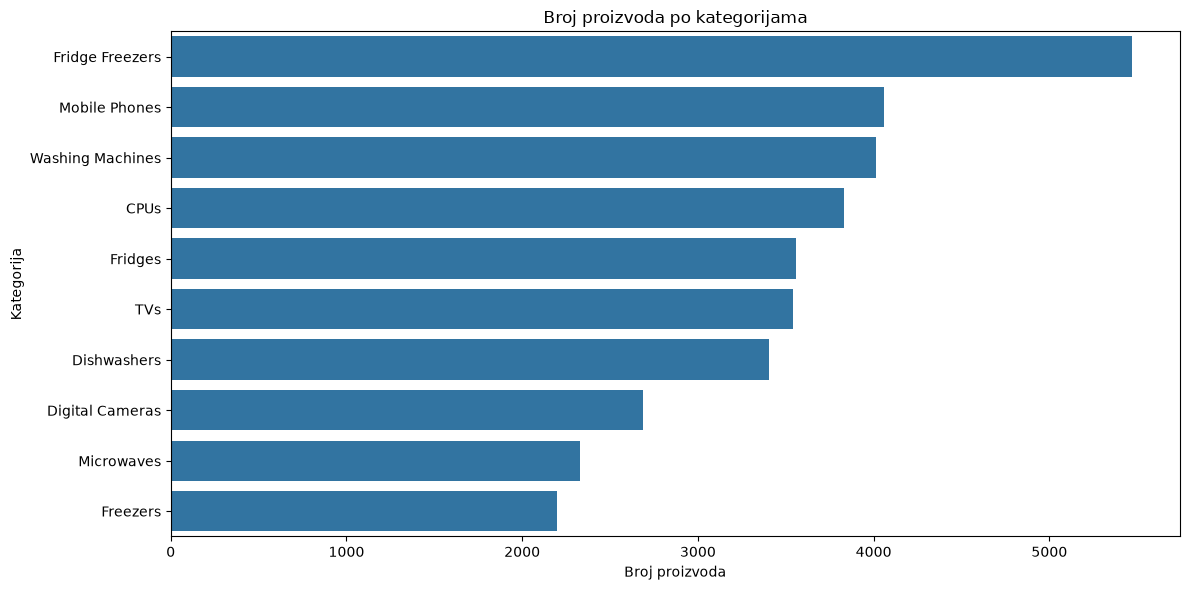

In [29]:
# Vizualizacija broja proizvoda po kategorijama

plt.figure(figsize=(12, 6))

category_counts_clean = df_clean["Category Label"].value_counts()

sns.barplot(
    x=category_counts_clean.values,
    y=category_counts_clean.index
)

plt.title("Broj proizvoda po kategorijama")
plt.xlabel("Broj proizvoda")
plt.ylabel("Kategorija")
plt.tight_layout()

plt.show()

In [30]:
# Analiza dužine naziva proizvoda

df_clean["title_length"] = df_clean["Product Title"].str.len()
df_clean["word_count"] = df_clean["Product Title"].str.split().str.len()

print("Statistika dužine naziva:")
print(df_clean["title_length"].describe())

print("\nStatistika broja riječi:")
print(df_clean["word_count"].describe())

Statistika dužine naziva:
count    35096.000000
mean        52.984813
std         22.438958
min          5.000000
25%         39.000000
50%         52.000000
75%         65.000000
max        200.000000
Name: title_length, dtype: float64

Statistika broja riječi:
count    35096.000000
mean         8.666144
std          4.164598
min          1.000000
25%          6.000000
50%          8.000000
75%         11.000000
max         37.000000
Name: word_count, dtype: float64


In [31]:
# Dodatne tekstualne karakteristike

df_clean["has_number"] = df_clean["Product Title"].str.contains(r"\d", regex=True)
df_clean["has_special_char"] = df_clean["Product Title"].str.contains(
    r"[^a-zA-Z0-9\s]", regex=True
)

print("Postotak naslova koji sadrže broj:")
print(df_clean["has_number"].mean() * 100)

print("\nPostotak naslova koji sadrže specijalni znak:")
print(df_clean["has_special_char"].mean() * 100)

Postotak naslova koji sadrže broj:
94.99658080692956

Postotak naslova koji sadrže specijalni znak:
22.598016868019148


In [32]:
# Priprema podataka za treniranje i testiranje

X = df_clean["Product Title"]
y = df_clean["Category Label"]

print("Broj uzoraka:", len(X))
print("Broj ciljnih kategorija:", y.nunique())

Broj uzoraka: 35096
Broj ciljnih kategorija: 10


In [33]:
# Podjela podataka na trening i test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Trening skup:", len(X_train))
print("Test skup:", len(X_test))

Trening skup: 28076
Test skup: 7020


In [34]:
# TF-IDF vektorizacija tekstualnih podataka

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Oblik trening matrice:", X_train_tfidf.shape)
print("Oblik test matrice:", X_test_tfidf.shape)

Oblik trening matrice: (28076, 29305)
Oblik test matrice: (7020, 29305)


In [35]:
# Prvi ML model - Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

logreg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logreg.fit(X_train_tfidf, y_train)

y_pred_logreg = logreg.predict(X_test_tfidf)

accuracy_logreg = accuracy_score(y_test, y_pred_logreg)

print("Logistic Regression accuracy:", accuracy_logreg)
print("\nClassification report:")
print(classification_report(y_test, y_pred_logreg))

Logistic Regression accuracy: 0.9561253561253561

Classification report:
                  precision    recall  f1-score   support

            CPUs       1.00      0.99      1.00       766
 Digital Cameras       0.99      0.99      0.99       538
     Dishwashers       0.98      0.92      0.95       681
        Freezers       0.98      0.92      0.95       440
 Fridge Freezers       0.90      0.95      0.93      1094
         Fridges       0.88      0.91      0.89       712
      Microwaves       0.99      0.95      0.97       466
   Mobile Phones       0.96      0.99      0.97       812
             TVs       0.98      0.98      0.98       708
Washing Machines       0.96      0.95      0.95       803

        accuracy                           0.96      7020
       macro avg       0.96      0.96      0.96      7020
    weighted avg       0.96      0.96      0.96      7020



In [36]:
# Drugi ML model - Linear SVM

from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    C=1.0,
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Linear SVM accuracy:", accuracy_svm)
print("\nClassification report:")
print(classification_report(y_test, y_pred_svm))

Linear SVM accuracy: 0.964957264957265

Classification report:
                  precision    recall  f1-score   support

            CPUs       1.00      1.00      1.00       766
 Digital Cameras       1.00      0.99      1.00       538
     Dishwashers       0.95      0.93      0.94       681
        Freezers       0.97      0.95      0.96       440
 Fridge Freezers       0.92      0.97      0.94      1094
         Fridges       0.93      0.92      0.93       712
      Microwaves       0.98      0.97      0.98       466
   Mobile Phones       0.98      0.99      0.98       812
             TVs       0.98      0.99      0.99       708
Washing Machines       0.97      0.94      0.95       803

        accuracy                           0.96      7020
       macro avg       0.97      0.96      0.97      7020
    weighted avg       0.97      0.96      0.96      7020



In [37]:
# Treći ML model - Naive Bayes

from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes accuracy:", accuracy_nb)
print("\nClassification report:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes accuracy: 0.9485754985754986

Classification report:
                  precision    recall  f1-score   support

            CPUs       1.00      1.00      1.00       766
 Digital Cameras       1.00      0.99      1.00       538
     Dishwashers       0.98      0.94      0.96       681
        Freezers       1.00      0.72      0.84       440
 Fridge Freezers       0.81      0.97      0.89      1094
         Fridges       0.93      0.86      0.89       712
      Microwaves       0.99      0.97      0.98       466
   Mobile Phones       0.99      0.99      0.99       812
             TVs       0.98      1.00      0.99       708
Washing Machines       0.96      0.96      0.96       803

        accuracy                           0.95      7020
       macro avg       0.96      0.94      0.95      7020
    weighted avg       0.95      0.95      0.95      7020



In [38]:
# Usporedba modela

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Naive Bayes"
    ],
    "Accuracy": [
        accuracy_logreg,
        accuracy_svm,
        accuracy_nb
    ]
})

print(model_results)

                 Model  Accuracy
0  Logistic Regression  0.956125
1           Linear SVM  0.964957
2          Naive Bayes  0.948575


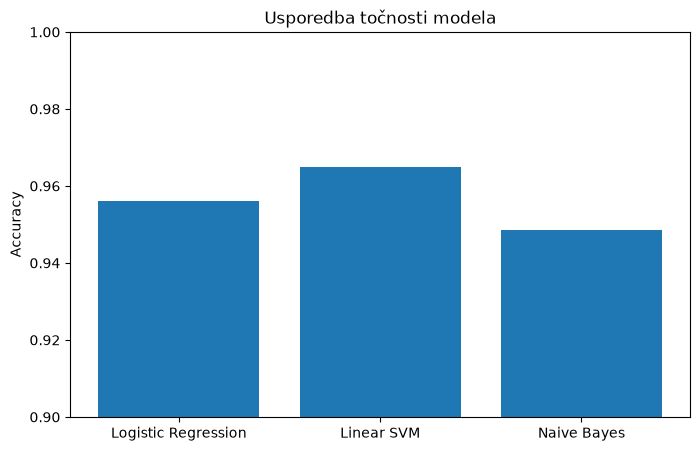

In [39]:
# Usporedba točnosti modela

plt.figure(figsize=(8, 5))

plt.bar(
    model_results["Model"],
    model_results["Accuracy"]
)

plt.title("Usporedba točnosti modela")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.0)

plt.show()

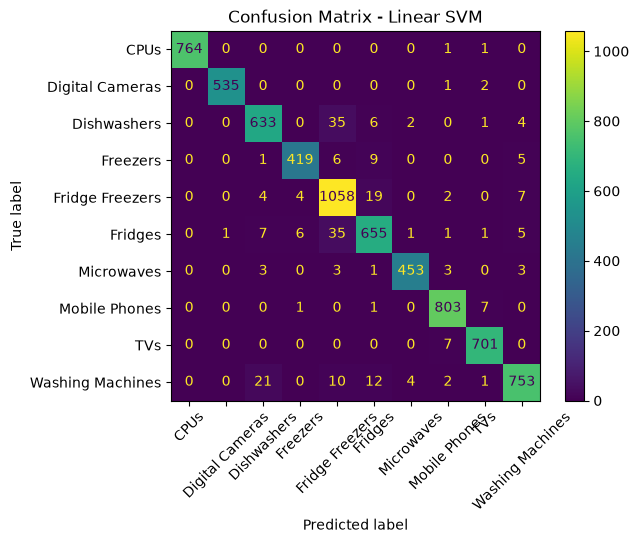

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion matrix za najbolji model
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    xticks_rotation=45
)

plt.title("Confusion Matrix - Linear SVM")
plt.show()

# Zaključak

U ovom projektu razvijen je model za klasifikaciju proizvoda prema kategoriji koristeći tekstualne podatke iz naziva proizvoda.

Nakon učitavanja i čišćenja podataka, dataset je sadržavao 35.096 proizvoda i 10 standardiziranih kategorija. Za pretvaranje tekstualnih podataka u numerički oblik korišten je TF-IDF.

Testirana su tri klasifikacijska modela:

- Logistic Regression: 95.61% accuracy
- Linear SVM: 96.50% accuracy
- Naive Bayes: 94.86% accuracy

Najbolji rezultat ostvario je Linear SVM s točnošću od 96.50%.

Confusion matrix pokazuje da model vrlo dobro razlikuje većinu kategorija, uz najviše pogrešaka između sličnih kategorija kao što su Fridges, Freezers i Fridge Freezers.

Na temelju dobivenih rezultata, Linear SVM odabran je kao najbolji model za klasifikaciju proizvoda.